# Dimensionality reduction and clustering

[Project home](https://github.com/ELounissi/Dimensionality_Reduction_Clustering) | [README](README.md) | [Full results](results/README.md)

Welcome! We will meet the datasets, visualize how representations affect clustering, and then reproduce the paper results.

This notebook reproduces the paper's tables and figures from its frozen per-run records. It explains each calculation and uses the same modules as `run_benchmark.py`.

Run the cells in order. The final section explains how to fit the complete benchmark from the source datasets. See [README.md](README.md) for installation and the full method settings.

## 1. Load the benchmark implementation

The notebook expects to be opened from the repository folder. NumPy, pandas, and SciPy versions are displayed so that the calculation environment is explicit.

In [1]:
import os
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[name] = "1"
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import scipy
from IPython.display import display, Markdown, Image
from benchmark import analysis as analysis
from benchmark.config import target_dimensions, ALGORITHM_SEEDS
from benchmark.validation import verify
from benchmark.report import build_report, markdown, signed_p, plain
root = Path.cwd()
assert (root / "run_benchmark.py").is_file(), "Open the notebook from the repository folder."
display(pd.DataFrame({"Component": ["Python", "NumPy", "pandas", "SciPy"],
                      "Version": [sys.version.split()[0], np.__version__, pd.__version__, scipy.__version__]}))

,Component,Version
0,Python,3.12.14
1,NumPy,2.2.2
2,pandas,2.2.3
3,SciPy,1.15.1


## 2. Verify the frozen records

The verification checks SHA-256 hashes, one result for each dataset/seed/representation/clusterer, the internal-score ranking of the recorded clustering settings, and all A9-A12 reference p-values. The candidate archive contains only the clustering grid used for the paper.

In [2]:
raw = verify(root)
units = analysis.units(raw)
metadata = raw[["dataset_id", "scope", "family", "n_samples", "n_features", "n_clusters"]].drop_duplicates()
display(metadata.groupby(["scope", "family"]).agg(Datasets=("dataset_id", "nunique"),
        Min_objects=("n_samples", "min"), Max_objects=("n_samples", "max")))
print(f"Reported clustering results: {len(raw):,}")

Verified 87,360 results, 1,185 datasets, and all A9-A12 p-values.


Datasets  Min_objects  Max_objects
scope     family                                        
real      real              20          106         2310
synthetic circles          300         2000         2000
          moons            300         2000         2000
          repliclust       300         2000         2000
          rsg              265           10         5000

Reported clustering results: 87,360


### A quick tour of dataset sizes

Each point below is one real dataset. The bar chart shows the number of datasets in each group. Notice how much the benchmark varies in sample size and feature count; the same reduction rule can therefore produce quite different target dimensions.

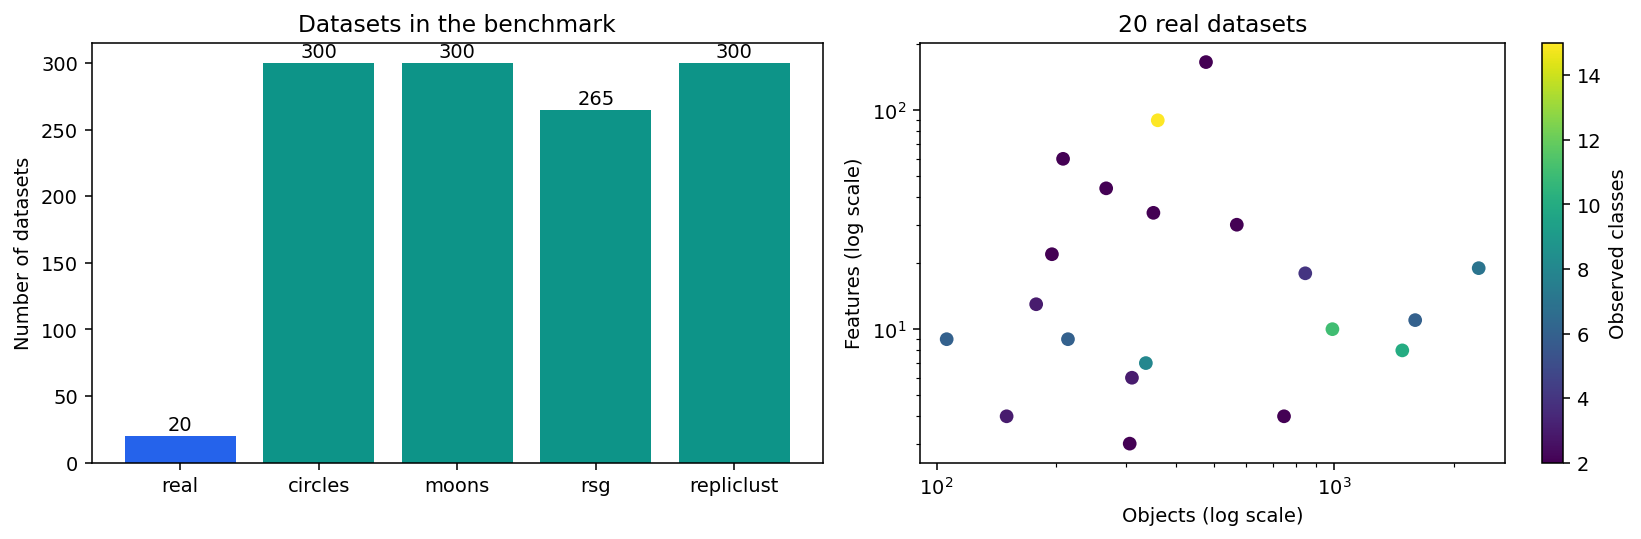

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = metadata.groupby("family").dataset_id.nunique().reindex(["real", "circles", "moons", "rsg", "repliclust"])
axes[0].bar(counts.index, counts.values, color=["#2563eb", "#0d9488", "#0d9488", "#0d9488", "#0d9488"])
axes[0].set(title="Datasets in the benchmark", ylabel="Number of datasets")
for index, value in enumerate(counts.values):
    axes[0].text(index, value + 4, str(value), ha="center")
real_metadata = metadata[metadata.scope == "real"]
points = axes[1].scatter(real_metadata.n_samples, real_metadata.n_features,
                         c=real_metadata.n_clusters, cmap="viridis", s=65, edgecolor="white")
axes[1].set(xscale="log", yscale="log", xlabel="Objects (log scale)",
            ylabel="Features (log scale)", title="20 real datasets")
fig.colorbar(points, ax=axes[1], label="Observed classes")
fig.tight_layout()
from io import BytesIO
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=140, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))
plt.close(fig)

## 3. Data sources and preprocessing

The 300 Circles, 300 Moons, 300 Repliclust, 265 RSG, and 20 real datasets are read from their public archives. Versioned source URLs, checksums, and licenses are in `assets/sources.json` and the README. SPECTF is the 44-feature UCI dataset. The full fitting command downloads and checks the inputs.

Identifiers and labels are removed from the feature matrix. Each feature is standardized to mean zero and unit variance before clustering or reduction. The known class count k is supplied to the benchmark. Individual class assignments are used for ARI evaluation.

In [4]:
real_data = metadata[metadata.scope == "real"].sort_values("dataset_id")
display(real_data[["dataset_id", "n_samples", "n_features", "n_clusters"]].reset_index(drop=True))

,dataset_id,n_samples,n_features,n_clusters
0,breast_tissue,106,9,6
1,breast_wisconsin,569,30,2
2,ecoli,336,7,8
3,glass,214,9,6
4,haberman,306,3,2
5,ionosphere,351,34,2
6,iris,150,4,3
7,movement_libras,360,90,15
8,musk,476,166,2
9,parkinsons,195,22,2


## 4. Dimension rules and model settings

PCA, RBF Kernel PCA, VAE, Isomap, and metric MDS are evaluated at three dimensions. The k-1 rule has a minimum of two; percentage rules use ceiling. All targets are capped below both the original feature count and the object count.

AHC uses the greatest silhouette, GMM the lowest BIC, and OPTICS the cluster count closest to k followed by the smallest noise fraction. Ties use the setting name in lexical order. OPTICS noise is attached to the closest cluster centroid. These rules also apply to no reduction. The README lists all parameters.

**What does each reducer try to preserve?**

| Method | A useful way to think about it |
| --- | --- |
| PCA | A linear view of the strongest variation |
| Kernel PCA | A nonlinear view built from similarities between objects |
| VAE | A compact representation learned through reconstruction and a probabilistic objective |
| Isomap | Distances measured along a neighborhood graph |
| MDS | Pairwise distances between objects |

**How do the clusterers form groups?**

| Approach | Main idea |
| --- | --- |
| k-means | Gather objects around centroids |
| AHC | Merge groups to build a hierarchy |
| GMM | Fit Gaussian distributions to represent group shapes |
| OPTICS | Follow changes in local density and reachability |

These are different views of structure, so the benchmark compares every reducer with every clusterer.


In [5]:
examples = [(2, 10, 2000), (5, 50, 2000), (2, 200, 10)]
display(pd.DataFrame([{"k": k, "d": d, "n": n, **target_dimensions(k, d, n)} for k, d, n in examples]))
print("Real-data algorithm seeds:", ALGORITHM_SEEDS)
print("Conditions per clusterer:", len(analysis.CONDS))

,k,d,n,k_minus_1,25_percent,50_percent
0,2,10,2000,2,3,5
1,5,50,2000,4,13,25
2,2,200,10,2,9,9


Real-data algorithm seeds: (11, 29, 47, 71, 101, 131, 173, 211, 257, 307)
Conditions per clusterer: 16


### See a representation and its clusters

For a small, quick illustration, we use scikit-learn's bundled Iris dataset: 150 flowers, four measurements, and three species. The full benchmark loads Iris from the checksummed archive described in the README.

The first panel colors the standardized data's two-dimensional PCA view by species. The next panels show k-means partitions fitted either to all four standardized measurements or to the two PCA components. Every panel uses the same projection so the partitions can be compared visually. Cluster numbers are arbitrary, so their colors need not match the species colors. ARI measures agreement regardless of cluster numbering.

This illustration helps explain the workflow. The paper's aggregate results are read from the frozen benchmark records in the following sections.

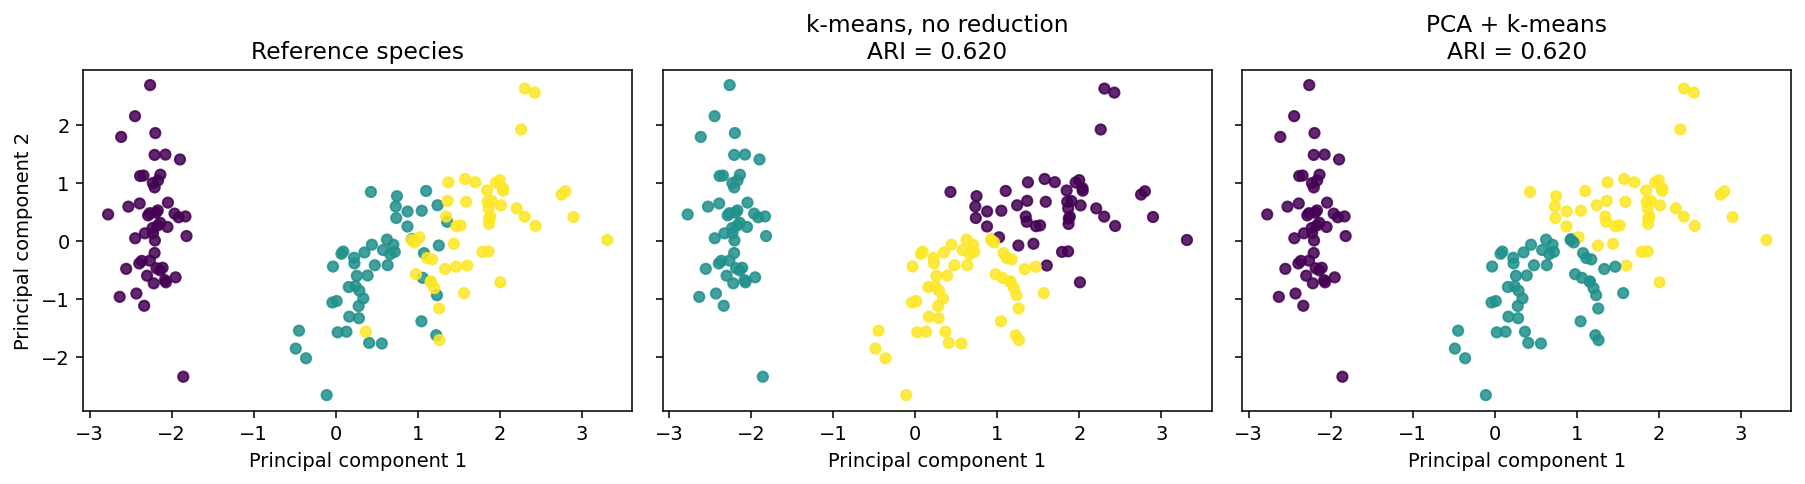

,Species,Objects
0,setosa,50
1,versicolor,50
2,virginica,50


In [6]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from benchmark.methods import reduce_cpu, cluster_all
iris = load_iris()
features = StandardScaler().fit_transform(iris.data)
projection, _ = reduce_cpu(features, "PCA", 2, 11)
_, original_labels, _ = cluster_all(features, "KMeans", 3, 11)[0]
_, reduced_labels, _ = cluster_all(projection, "KMeans", 3, 11)[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True, sharey=True)
labels_and_titles = [
    (iris.target, "Reference species"),
    (original_labels, f"k-means, no reduction\nARI = {adjusted_rand_score(iris.target, original_labels):.3f}"),
    (reduced_labels, f"PCA + k-means\nARI = {adjusted_rand_score(iris.target, reduced_labels):.3f}"),
]
for axis, (labels, title) in zip(axes, labels_and_titles):
    axis.scatter(projection[:, 0], projection[:, 1], c=labels, cmap="viridis", s=28, alpha=.85)
    axis.set(title=title, xlabel="Principal component 1")
axes[0].set_ylabel("Principal component 2")
fig.tight_layout()
from io import BytesIO
image_buffer = BytesIO()
fig.savefig(image_buffer, format="png", dpi=140, bbox_inches="tight")
display(Image(data=image_buffer.getvalue()))
plt.close(fig)
display(pd.DataFrame({"Species": iris.target_names,
                      "Objects": np.bincount(iris.target)}))

## 5. Average repeats before comparing datasets

Real ARI values are averaged over ten algorithm seeds within each dataset. Synthetic datasets each contribute one run per condition. For synthetic significance tests and boxplots, replicates are averaged within the 45 configurations first. Family ARI tables instead give each dataset equal weight and report the sample standard deviation across datasets.

In [7]:
configurations = analysis.configurations(units)
display(pd.DataFrame({"Scope": ["Real", "Synthetic"], "Independent comparison units": [20, configurations.unit.nunique()],
                      "Unit": ["Dataset mean over 10 seeds", "Configuration mean over replicates"]}))
assert len(units) == 75840
assert len(configurations) == 2880

,Scope,Independent comparison units,Unit
0,Real,20,Dataset mean over 10 seeds
1,Synthetic,45,Configuration mean over replicates


## 6. Inspect a paired comparison

The example below compares AHC after Kernel PCA at k-1 with AHC without reduction. Differences pair the same real dataset. A positive difference means improved ARI. The one-sided alternative is ARI_DR > ARI_NoDR.

In [8]:
example = units[(units.scope == "real") & (units.clusterer == "AHC")].pivot(index="dataset_id", columns="condition", values="ari")
paired = example[["None__original", "KernelPCA__k_minus_1"]].copy()
paired.columns = ["No reduction", "Kernel PCA k-1"]
paired["ARI change"] = paired.iloc[:, 1] - paired.iloc[:, 0]
display(paired.round(4))
display(pd.Series(analysis.test(paired["ARI change"], "greater"), name="Paired comparison"))

,No reduction,Kernel PCA k-1,ARI change
dataset_id,,,
breast_tissue,0.1562,0.2667,0.1105
breast_wisconsin,0.0048,0.7129,0.7081
ecoli,0.7261,0.4296,-0.2965
glass,0.0212,0.2000,0.1788
haberman,0.0116,-0.0059,-0.0175
ionosphere,0.0045,0.1920,0.1876
iris,0.5584,0.6410,0.0826
movement_libras,0.3145,0.3720,0.0576
musk,-0.0019,0.0024,0.0043


n_units              20.000000
n_nonzero            20.000000
wins                 16.000000
ties                  0.000000
losses                4.000000
mean_delta_ari        0.113964
median_delta_ari      0.090698
rank_biserial         0.685714
statistic           177.000000
p_raw                 0.002790
Name: Paired comparison, dtype: float64

## 7. Rebuild all paper outputs

The report writes Tables 1-5, A1-A12, Figures 1-10, and Figure A.1. Tables have full-precision CSV records and LaTeX bodies. Synthetic ARI tables include mean ± standard deviation. Figure 1 is the original bundled illustration; the remaining figures are calculated from the result records.

In [9]:
units, statistics = build_report(root / "frozen/raw_results.csv.gz", root / "results")
display(Markdown("[Open every table and figure](results/README.md)"))

Generated Tables 1-5, A1-A12, and Figures 1-10 and A.1.


[Open every table and figure](results/README.md)

## 8. Read Tables A9 and A10

A9 uses 45 synthetic configuration means and a two-sided test. A10 uses 20 real dataset means and a one-sided improvement test. Both use Pratt zero handling. Signs describe the mean ARI change; they are not signs of p-values. Bold indicates nominal p < 0.05. For consistency with the manuscript, values below 0.001 display as 0.001 here. Exact and Holm-adjusted p-values remain available in the CSV files.

In [10]:
headers = ["Clusterer"] + [plain(r) + " " + l.replace("_minus_", "-").replace("_percent", "%") for r in analysis.RS for l in analysis.LS]
for number, scope in [(9, "Synthetic"), (10, "Real")]:
    table = statistics[number]
    rows = []
    for clusterer in analysis.CS:
        block = table[table.clusterer == clusterer].set_index("condition").reindex(analysis.CONDS[1:])
        rows.append([plain(clusterer)] + [signed_p(row) for row in block.itertuples()])
    display(Markdown(f"### Table A{number}: {scope} data\n\n" + markdown(headers, rows)))
    print(f"A{number}: {(table.p_raw < .05).sum()} nominally significant; {(table.p_holm_60 < .05).sum()} after Holm correction across 60 tests.")

### Table A9: Synthetic data

| Clusterer | PCA k-1 | PCA 25% | PCA 50% | Kernel PCA k-1 | Kernel PCA 25% | Kernel PCA 50% | VAE k-1 | VAE 25% | VAE 50% | Isomap k-1 | Isomap 25% | Isomap 50% | MDS k-1 | MDS 25% | MDS 50% |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| k-means | **-0.001** | **-0.002** | **-0.015** | **+0.043** | +0.163 | **+0.029** | -0.143 | -0.576 | +0.964 | **+0.007** | **+0.028** | **+0.009** | -0.057 | **-0.007** | **-0.008** |
| AHC | +0.071 | **-0.032** | -0.256 | **+0.001** | +0.064 | **+0.010** | +0.553 | +0.955 | +0.806 | **+0.001** | **+0.006** | **+0.001** | **+0.004** | -0.171 | -0.786 |
| GMM | -0.546 | -0.357 | +0.752 | +0.230 | +0.804 | +0.991 | **-0.001** | **-0.027** | -0.143 | -0.701 | +0.773 | +0.446 | **-0.040** | -0.219 | -0.103 |
| OPTICS | -0.964 | -0.860 | -0.486 | **+0.032** | +0.055 | +0.071 | +0.117 | **+0.009** | **+0.016** | **+0.001** | **+0.005** | +0.066 | +0.471 | -0.910 | -0.518 |


A9: 25 nominally significant; 4 after Holm correction across 60 tests.


### Table A10: Real data

| Clusterer | PCA k-1 | PCA 25% | PCA 50% | Kernel PCA k-1 | Kernel PCA 25% | Kernel PCA 50% | VAE k-1 | VAE 25% | VAE 50% | Isomap k-1 | Isomap 25% | Isomap 50% | MDS k-1 | MDS 25% | MDS 50% |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| k-means | -0.917 | +0.910 | -0.424 | +0.062 | +0.420 | +0.101 | +0.249 | +0.205 | +0.311 | +0.156 | +0.522 | +0.249 | -0.826 | -0.390 | +0.515 |
| AHC | +0.053 | +0.500 | +0.663 | **+0.003** | **+0.013** | **+0.005** | **+0.027** | +0.057 | **+0.022** | **+0.036** | **+0.004** | **+0.016** | +0.168 | +0.414 | +0.074 |
| GMM | -0.522 | -0.929 | -0.324 | -0.869 | -0.853 | -0.715 | -0.774 | -0.727 | -0.663 | -0.918 | -0.806 | -0.806 | -0.785 | -0.774 | -0.622 |
| OPTICS | **+0.046** | +0.160 | +0.072 | **+0.004** | **+0.004** | **+0.020** | **+0.006** | **+0.012** | +0.238 | **+0.016** | +0.159 | **+0.016** | +0.241 | **+0.042** | +0.175 |


A10: 17 nominally significant; 0 after Holm correction across 60 tests.


## 9. Read Tables A11 and A12

Reducer scores average the three reduction levels and four clusterers per real dataset. The no-reduction score averages its four baselines once. Clusterer scores average all 16 conditions. The paired tests therefore use 20 dataset values, not pooled seed records. The lower triangle shows the direction of row minus column.

In [11]:
for number, order in [(11, ["None"] + analysis.RS), (12, analysis.CS)]:
    table = statistics[number]
    rows = []
    for j, name in enumerate(order):
        row = [plain(name)]
        for k, other in enumerate(order):
            if k >= j:
                row.append("-")
            else:
                value = table[(table.row == other) & (table.column == name)].iloc[0].copy()
                value["mean_delta_ari"] *= -1
                row.append(signed_p(value))
        rows.append(row)
    display(Markdown(f"### Table A{number}\n\n" + markdown([""] + [plain(x) for x in order], rows)))

### Table A11

|  | No reduction | PCA | Kernel PCA | VAE | Isomap | MDS |
| --- | --- | --- | --- | --- | --- | --- |
| No reduction | - | - | - | - | - | - |
| PCA | +0.177 | - | - | - | - | - |
| Kernel PCA | **+0.001** | +0.058 | - | - | - | - |
| VAE | **+0.001** | +0.105 | -0.105 | - | - | - |
| Isomap | **+0.033** | +0.475 | **-0.033** | -0.674 | - | - |
| MDS | +0.202 | -0.452 | **-0.011** | **-0.009** | -0.154 | - |


### Table A12

|  | k-means | AHC | GMM | OPTICS |
| --- | --- | --- | --- | --- |
| k-means | - | - | - | - |
| AHC | **-0.006** | - | - | - |
| GMM | +0.330 | **+0.003** | - | - |
| OPTICS | -0.058 | +0.546 | **-0.024** | - |


## 10. Inspect the reducer-clusterer pattern

Each heatmap cell is the largest of three mean real-data gains for that reducer and clusterer. It is not an average of dataset-specific maxima. Stars identify nominal fixed-condition p < 0.05 at the displayed level. None of the 60 real fixed-condition comparisons survives Holm correction.

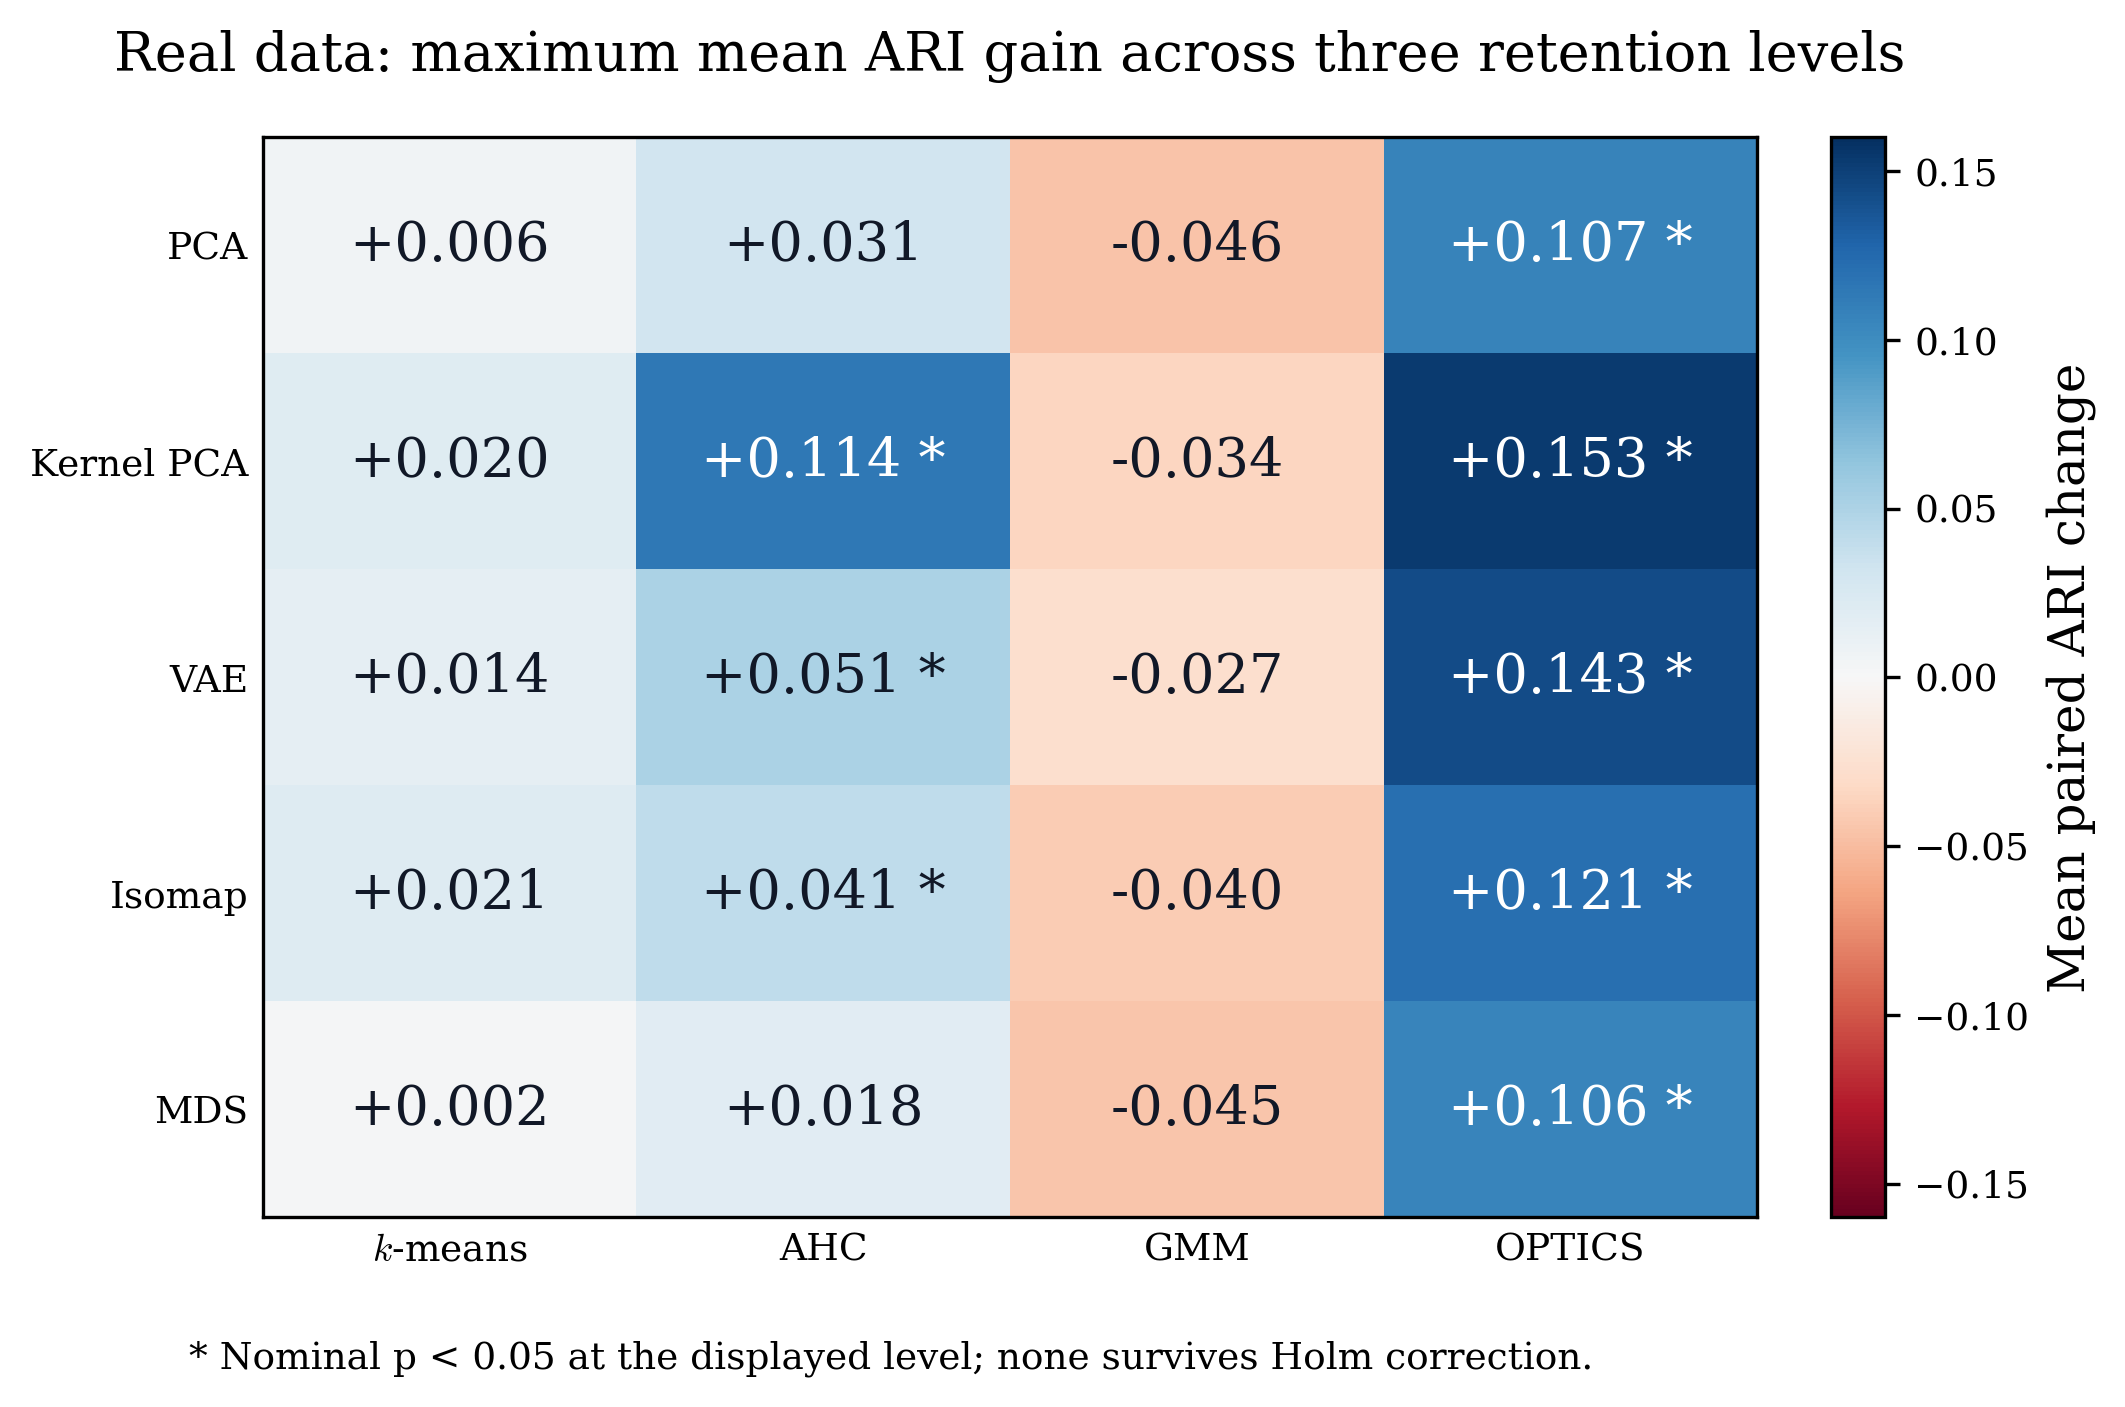

,clusterer,reducer,reduction_level,mean_delta_ari,p_raw,p_holm_60
0,OPTICS,KernelPCA,k_minus_1,0.152742,0.003774,0.222688
1,OPTICS,VAE,k_minus_1,0.142758,0.006481,0.356479
2,OPTICS,Isomap,k_minus_1,0.120997,0.016455,0.833761
3,AHC,KernelPCA,k_minus_1,0.113964,0.002790,0.167427
4,OPTICS,PCA,k_minus_1,0.106555,0.045627,1.000000
5,OPTICS,MDS,25_percent,0.106077,0.042489,1.000000
6,AHC,VAE,50_percent,0.050619,0.022027,1.000000
7,AHC,Isomap,25_percent,0.040528,0.004185,0.242736
8,AHC,PCA,k_minus_1,0.031226,0.053437,1.000000
9,KMeans,Isomap,k_minus_1,0.020843,0.155897,1.000000


In [12]:
display(Image(filename=str(root / "results/figures/figure_11.png"), width=850))
levels = analysis.read(root / "results/tables/figure_A1_levels.csv")
display(levels[["clusterer", "reducer", "reduction_level", "mean_delta_ari", "p_raw", "p_holm_60"]].round(6))

AHC and OPTICS have the largest real-data gains, particularly with Kernel PCA. GMM's highest mean real ARI is obtained without reduction. k-means shows smaller mean improvements without nominal significance in A10. Synthetic results differ across data families; the complete ARI tables and adjusted p-values should accompany these summaries.

## 11. Fit the complete benchmark from the data

After installing the pinned dependencies and a RAR extractor, run the following in a terminal from this folder:

```bash
python run_benchmark.py --workers 4
```

This downloads about 1.6 GB of source archives and fits the complete benchmark. Results go to `runs/full/`. Repeating the command resumes completed datasets when the source code, data, and environment match. To inspect the runner options:

```bash
python run_benchmark.py --help
```

The full-run command calls the same loaders, reducers, clusterers, and reporting functions described here. Frozen-result regeneration and new model fitting are separate commands because only the former guarantees reproduction of the archived numerical records across machines.

### Run the paper benchmark here

This cell calls the repository's top-level benchmark program directly. Set the flag to `True` when you are ready for the complete run. It downloads about 1.6 GB of source data, uses the pinned method settings, and saves results to `runs/full/`. Keep the flag `False` for a quick notebook walkthrough. Completed datasets can be resumed using the same output directory.

In [13]:
import subprocess
RUN_FULL_BENCHMARK = False
WORKERS = 4
if RUN_FULL_BENCHMARK:
    subprocess.run([sys.executable, str(root / "run_benchmark.py"), "--workers", str(WORKERS)],
                   cwd=root, check=True)
else:
    display(Markdown("**Ready to run the full benchmark:** set `RUN_FULL_BENCHMARK = True` above. "
                     "The command is `python run_benchmark.py --workers 4`."))

**Ready to run the full benchmark:** set `RUN_FULL_BENCHMARK = True` above. The command is `python run_benchmark.py --workers 4`.